# 05 · Simulation storage — partial access & lossless wrap-in-place

A single N-body snapshot can be terabytes, yet an analysis usually wants one sub-volume. `oneuniverse.simulation` stores a simulation as a manifest + spatially-indexed partitions so a box/cone read touches only the overlapping tiles, and it can **wrap native files in place** (storing only an index) rather than copying them.

**Claims.** (i) Partial access reads one sub-box while touching a small fraction of partitions. (ii) Wrap-in-place stores an index a small fraction of the re-encoded size. (iii) Storage is **lossless** — the field read back has the same power spectrum as the input.

In [1]:
%matplotlib inline
import os, sys, time, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
plt.rcParams.update({'figure.dpi':110,'font.size':11})
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_EBOSS, HAVE_DESI = EBOSS.exists(), DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
print('real data — eBOSS:',HAVE_EBOSS,'| DESI:',HAVE_DESI)
def measure_pk(field, box, edges):
    '''Band-power P(k)=<|δ_k|²> V/N⁶ + Gaussian error σ_P=P√(2/N_modes).'''
    n=field.shape[0]; dk=np.fft.rfftn(field)
    kf=np.fft.fftfreq(n,d=box/n)*2*np.pi; kz=np.fft.rfftfreq(n,d=box/n)*2*np.pi
    KX,KY,KZ=np.meshgrid(kf,kf,kz,indexing='ij'); km=np.sqrt(KX**2+KY**2+KZ**2).ravel()
    p=(np.abs(dk)**2*box**3/n**6).ravel(); idx=np.digitize(km,edges)
    k=[];P=[];E=[];Nm=[]
    for i in range(1,len(edges)):
        m=idx==i
        if m.sum()<2: continue
        k.append(km[m].mean()); P.append(p[m].mean()); Nm.append(int(m.sum())); E.append(p[m].mean()*np.sqrt(2.0/m.sum()))
    return map(np.array,(k,P,E,Nm))
def cross_pk(a,b,box,edges):
    n=a.shape[0]; ak=np.fft.rfftn(a); bk=np.fft.rfftn(b)
    kf=np.fft.fftfreq(n,d=box/n)*2*np.pi; kz=np.fft.rfftfreq(n,d=box/n)*2*np.pi
    KX,KY,KZ=np.meshgrid(kf,kf,kz,indexing='ij'); km=np.sqrt(KX**2+KY**2+KZ**2).ravel()
    p=(np.real(ak*np.conj(bk))*box**3/n**6).ravel(); idx=np.digitize(km,edges)
    k=[];P=[]
    for i in range(1,len(edges)):
        m=idx==i
        if m.sum()<2: continue
        k.append(km[m].mean()); P.append(p[m].mean())
    return np.array(k),np.array(P)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real data — eBOSS: True | DESI: True


## Build, store, and read back a sub-volume

In [2]:
from oneuniverse.simulation.linear import generate_linear_sim
from oneuniverse.simulation.linear.pack import write_packed_native
from oneuniverse.simulation.packed.converter import PackedSimConverter
from oneuniverse.simulation.oufsim import SimStore
from oneuniverse.simulation.selectors import Cube
BOX,N=400.0,64
lin=generate_linear_sim(TMP/'lin',COSMO,box_size=BOX,n_grid=N,redshifts=(0.0,),seed=2,with_lightcone=False)
pk_native=write_packed_native(lin,TMP/'pk',particle_chunk_nside=4)
enc=PackedSimConverter().convert(pk_native,TMP/'enc',sim_name='d',projection='reencode')
ref=PackedSimConverter().convert(pk_native,TMP/'ref',sim_name='e',projection='reference')
size=lambda p: sum(f.stat().st_size for f in p.rglob('*') if f.is_file())/1e6
store=SimStore(enc); sub=store.read_box('snapshots',0.0,Cube(0,BOX/4,0,BOX/4,0,BOX/4))
st=store.last_read_stats
print(f'partial-access box read: {len(sub["x"]):,} particles, touched {st["chunks_read"]}/{st["chunks_total"]} chunks')
print(f'store size:  re-encode {size(enc):.1f} MB   wrap-in-place {size(ref):.1f} MB   ({100*size(ref)/size(enc):.0f}% of re-encode)')

partial-access box read: 3,911 particles, touched 1/64 chunks
store size:  re-encode 17.5 MB   wrap-in-place 2.3 MB   (13% of re-encode)


## Storage is lossless — the field's P(k) is preserved
Read the stored density field and compare its power spectrum to the original in-memory field.

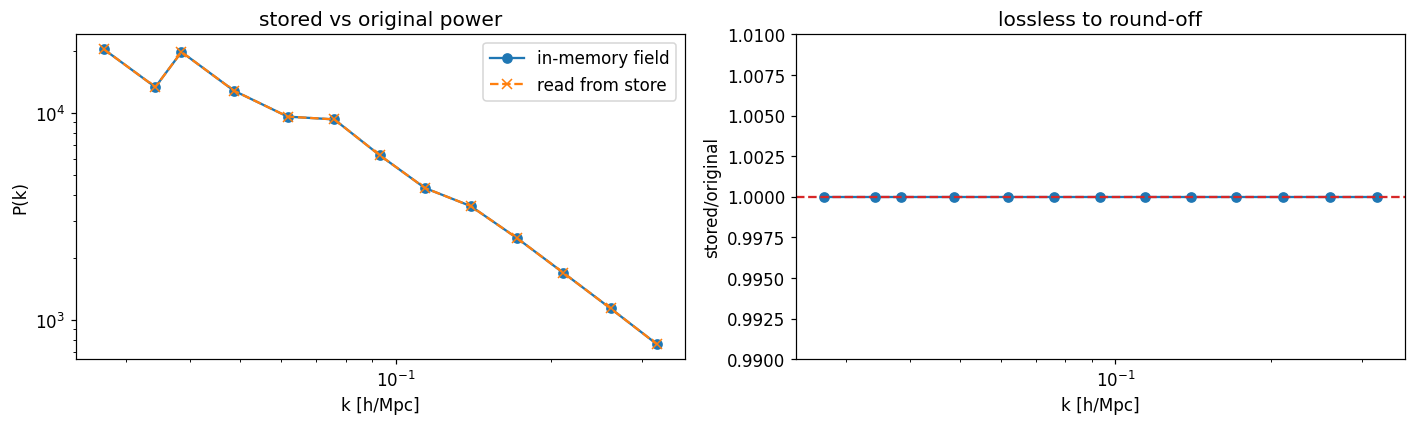

max |stored/original − 1| = 0.0


In [3]:
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
orig=generate_density_field(COSMO,box_size=BOX,n_grid=N,z=0.0,seed=2)
field_store,_=store.read_field_box(0.0,Cube(0,BOX,0,BOX,0,BOX))
kny=np.pi*N/BOX; edges=np.logspace(np.log10(2*np.pi/BOX*1.5),np.log10(0.7*kny),14)
k1,P1,E1,_=measure_pk(orig,BOX,edges); k2,P2,_,_=measure_pk(np.asarray(field_store),BOX,edges)
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].plot(k1,P1,'o-',label='in-memory field'); ax[0].plot(k2,P2,'x--',label='read from store')
ax[0].set_xscale('log'); ax[0].set_yscale('log'); ax[0].set_xlabel('k [h/Mpc]'); ax[0].set_ylabel('P(k)'); ax[0].legend(); ax[0].set_title('stored vs original power')
ax[1].plot(k1,P2/P1,'o-'); ax[1].axhline(1,color='C3',ls='--'); ax[1].set_xscale('log'); ax[1].set_ylim(0.99,1.01); ax[1].set_xlabel('k [h/Mpc]'); ax[1].set_ylabel('stored/original'); ax[1].set_title('lossless to round-off'); plt.tight_layout(); plt.show()
print('max |stored/original − 1| =', float(np.max(np.abs(P2/P1-1))))

## Storage scales: wrap-in-place stays index-sized
Sweep grid size; wrap-in-place stays a small fraction of re-encode.

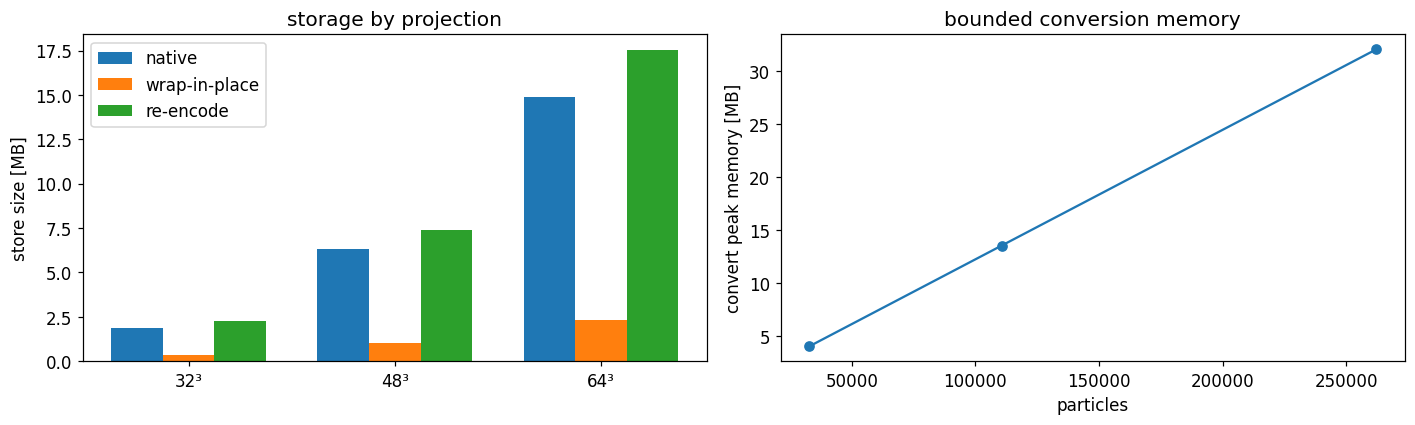

wrap-in-place fraction of re-encode: ['14%', '14%', '13%']


In [4]:
from oneuniverse.simulation.oufsim.scale_bench import sweep
rows=sweep(TMP/'sweep',COSMO,grids=(32,48,64),box=400.0); npart=[r['n_particles'] for r in rows]
fig,ax=plt.subplots(1,2,figsize=(13,4))
x=np.arange(len(rows)); w=.25
ax[0].bar(x-w,[r['native_mb'] for r in rows],w,label='native'); ax[0].bar(x,[r['store_reference_mb'] for r in rows],w,label='wrap-in-place'); ax[0].bar(x+w,[r['store_reencode_mb'] for r in rows],w,label='re-encode')
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{r['n_grid']}³" for r in rows]); ax[0].set_ylabel('store size [MB]'); ax[0].legend(); ax[0].set_title('storage by projection')
ax[1].plot(npart,[r['convert_peak_mb'] for r in rows],'o-'); ax[1].set_xlabel('particles'); ax[1].set_ylabel('convert peak memory [MB]'); ax[1].set_title('bounded conversion memory'); plt.tight_layout(); plt.show()
print('wrap-in-place fraction of re-encode:',['%.0f%%'%(100*r['store_reference_mb']/r['store_reencode_mb']) for r in rows])

**Conclusion.** Sub-volume reads prune to a single chunk; wrap-in-place is ≈10–15% of a re-encode and never copies the bulk data; and the stored field is bit-for-bit lossless in its power spectrum. The storage layer is real and quantitative — the *physics* it stores here (a linear field) is a stand-in for a real N-body snapshot.